## Visualizing: Volcano Plot and Heatmap

This notebook turns the differential expression results into two complementary visual summaries. The volcano plot gives an overview of fold change and statistical significance across all genes, while the heatmap focuses on the top differentially expressed genes to check whether tumor and normal samples show distinct expression patterns.

1. Load the differential expression results and processed expression data
2. Prepare the variables needed for the volcano plot
3. Generate and interpret the volcano plot
4. Select the top differentially expressed genes for the heatmap
5. Standardize, organize and build the heatmap 

In [1]:
# Import the libraries used to prepare and plot the differential-expression results

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Resolve the project root and define the data and results folders

project_root = Path.cwd()
if not (project_root / "data").exists():
    project_root = project_root.parent

# Get data path
data_path = str(project_root) + "/data"

# Get results path
result_path = str(project_root) + "/results"

# Step 1: Load data

We load the differential expression table produced in the previous notebook together with the cleaned expression matrix `X` and the sample labels `y`. This gives us the gene-level statistics needed for the volcano plot and the sample-level expression values needed for the heatmap.

In [3]:
# Load the differential-expression results together with the cleaned expression data

results = pd.read_csv(result_path + "/tables/differential_expression_results.csv", index_col=0)
X = pd.read_csv(data_path + "/processed/X_clean.csv")
y = pd.read_csv(data_path + "/processed/y_clean.csv").squeeze()

# Step 2: Prepare data for plotting

To build the volcano plot, we convert adjusted p-values to `-log10(adj_p_value)`. This makes very small adjusted p-values easier to visualize: the more statistically significant a gene is, the higher it appears on the plot.

We also assign each gene to one of three categories using the thresholds `adj_p_value < 0.05` and `|log2FC| > 1`. Genes with positive log2 fold change are labeled as upregulated in tumor, genes with negative log2 fold change are labeled as downregulated in tumor, and all remaining genes are grouped as not significant.

These cutoffs help us focus on genes that are not only statistically significant but also show a difference in expression large enough to be biologically meaningful.

In [4]:
# Create the plotting variables and label genes by significance category

results = results.copy()

results["neg_log10_adj_p"] = -np.log10(results["adj_p_value"] + 1e-300)

results["significance"] = "Not significant"
results.loc[
    (results["adj_p_value"] < 0.05) & (results["log2FC"] > 1),
    "significance"
] = "Upregulated in tumor"

results.loc[
    (results["adj_p_value"] < 0.05) & (results["log2FC"] < -1),
    "significance"
] = "Downregulated in tumor"

results["gene"] = results.index
results.head()

,mean_tumor,mean_normal,log2FC,p_value,adj_p_value,neg_log10_adj_p,significance,gene
1007_s_at,10.392065,10.219646,0.172420,0.361709,0.445466,0.351185,Not significant,1007_s_at
1053_at,7.569988,6.428852,1.141136,0.000040,0.000491,3.309303,Upregulated in tumor,1053_at
117_at,6.363503,5.527662,0.835841,0.000663,0.003954,2.402919,Not significant,117_at
121_at,7.299507,7.587111,-0.287604,0.131963,0.198527,0.702180,Not significant,121_at
1255_g_at,3.172048,3.322261,-0.150213,0.053255,0.098941,1.004625,Not significant,1255_g_at


# Step 3: Volcano visualization

A volcano plot is useful here because it shows two key quantities for every gene at the same time: the size of the expression change on the x-axis and the strength of the statistical evidence on the y-axis. This makes it easier to spot genes with strong and reliable differences between the two groups.


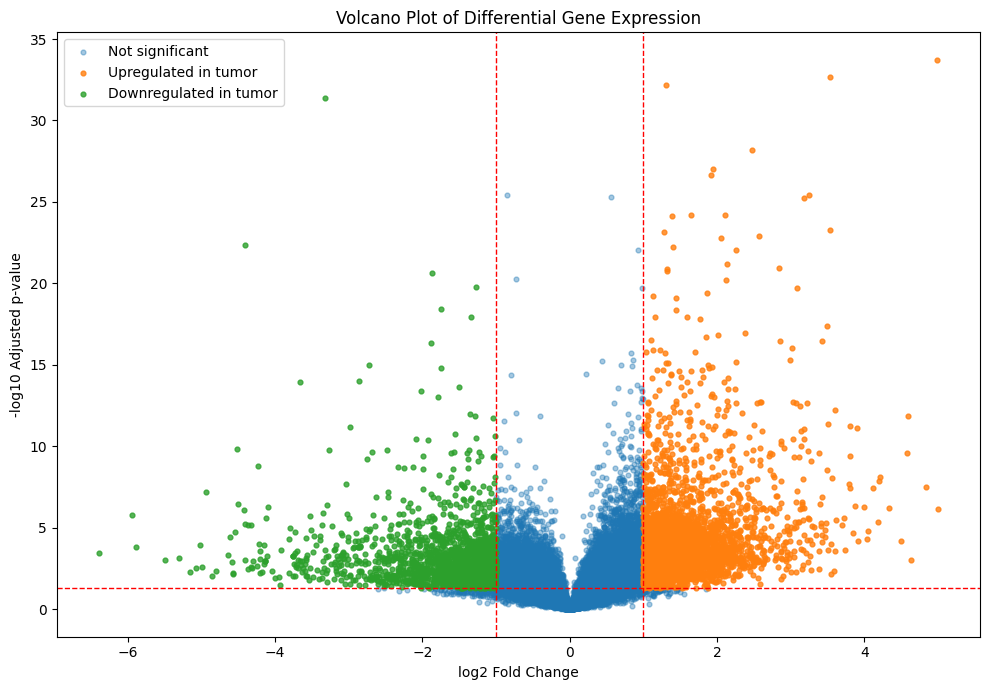

In [14]:
# Draw the volcano plot and add the decision thresholds used in the analysis

plt.figure(figsize=(10, 7))

for category, alpha in [
    ("Not significant", 0.4),
    ("Upregulated in tumor", 0.8),
    ("Downregulated in tumor", 0.8),
]:
    subset = results[results["significance"] == category]
    plt.scatter(
        subset["log2FC"],
        subset["neg_log10_adj_p"],
        label=category,
        alpha=alpha,
        s=12
    )

plt.axvline(x=1, linestyle="--", linewidth=1, color="red")
plt.axvline(x=-1, linestyle="--", linewidth=1, color="red")
plt.axhline(y=-np.log10(0.05), linestyle="--", linewidth=1, color="red")

plt.xlabel("log2 Fold Change")
plt.ylabel("-log10 Adjusted p-value")
plt.title("Volcano Plot of Differential Gene Expression")
plt.legend()
plt.tight_layout()
plt.savefig(result_path + "/figures/volcano_plot.png")
plt.show()

### Reading the volcano plot

Most genes form a dense central cloud near `log2FC = 0` and below the significance cutoff. This suggests that for a large part of the transcriptome, the difference between tumor and normal samples is small or not strong enough to stand out after multiple-testing correction.

Genes on the right side of the plot are more highly expressed in tumor samples, while genes on the left side are relatively more expressed in normal tissue. Points that appear higher on the plot have smaller adjusted p-values and therefore stronger statistical support.

The red threshold lines help separate genes with both meaningful fold change and significant adjusted p-values from the larger background cloud. The widening shape of the plot is typical in differential expression analysis and shows that the strongest signals tend to appear farther away from the center.

Overall, the figure suggests that the tumor and normal groups differ on more than just a few isolated genes. There is a visible set of genes on both sides of the plot that combine strong effect size with strong significance, which supports the presence of a clear transcriptional difference between the two conditions.

# Step 4: Select the most strongly deregulated genes

For the heatmap, we keep the 25 genes with the smallest adjusted p-values. This selection highlights the genes with the strongest statistical evidence for differential expression while keeping the figure compact enough to stay readable.

The goal is not to display every significant gene, but to focus on a small set of informative candidates and examine whether their expression patterns separate tumor and normal samples.

In [6]:
# Select the top genes with the smallest adjusted p-values for the heatmap

top_heatmap_genes = results.sort_values("adj_p_value").head(25).index.tolist()
X_top = X[top_heatmap_genes].copy()
X_top.head()

,217428_s_at,211122_s_at,1552264_a_at,219935_at,AFFX-HUMISGF3A/M97935_MA_at,222262_s_at,208502_s_at,223381_at,218208_at,220938_s_at,...,205167_s_at,210163_at,218748_s_at,202037_s_at,239511_s_at,200039_s_at,205943_at,236641_at,204962_s_at,213310_at
0,7.010762,7.659279,8.671009,5.965571,9.566412,7.284824,6.566984,8.195881,7.509812,7.379054,...,6.536618,6.199107,6.889451,8.995033,4.768033,10.790632,6.418596,7.751831,9.945552,9.082004
1,6.252760,10.009306,8.105795,6.530122,10.400595,5.831358,8.288193,8.467876,8.377331,7.408371,...,6.638949,8.798127,6.822160,11.354715,5.775884,11.192282,6.760475,6.989303,8.981863,6.448366
2,3.449416,7.178463,8.752115,4.861477,9.569712,8.516272,7.697956,9.384264,7.587440,7.338189,...,7.345492,5.722341,7.502165,12.031450,5.754115,11.226535,6.930507,7.779107,10.465526,8.633862
3,6.303300,10.060720,7.205984,6.901086,11.539292,6.789013,4.969144,8.250647,7.907464,7.435167,...,6.986744,8.676259,6.474023,6.054542,5.148902,11.313228,8.947065,6.462217,9.329730,8.134212
4,7.491796,9.404222,7.732480,6.375445,10.481122,7.090974,6.890452,7.370087,7.066052,6.849208,...,5.534879,8.141759,6.991715,10.416699,5.664785,11.329723,7.628529,7.013902,9.701634,7.414218


### Standardize gene expression

Before plotting the heatmap, we standardize each selected gene across samples using a z-score. This puts all genes on a comparable scale, so the colors reflect relative overexpression or underexpression rather than raw expression magnitude.

Without this step, genes with larger absolute values would dominate the color scale and make cross-gene pattern comparison harder.

In [7]:
# Standardize each selected gene so their patterns are comparable across samples

X_top_scaled = (X_top - X_top.mean(axis=0)) / X_top.std(axis=0)

# Step 5: Building a heatmap

The heatmap complements the volcano plot by moving from a gene-level summary to a sample-level view. It lets us check whether the top differentially expressed genes produce distinct expression patterns for tumor and normal samples.

If the two groups form separate blocks of color and cluster apart from each other, that supports the idea that the differential expression signal is biologically meaningful rather than mostly driven by noise.

### Organize samples and annotations

We align the scaled expression matrix with the sample labels and create a color annotation bar for the phenotype of each sample. This makes it easier to compare the unsupervised clustering from the heatmap with the known class labels and see whether the visual grouping matches the biology.

In [13]:
# Order samples by label and build the color annotation for the heatmap columns

sample_order = y.sort_values().index
X_top_scaled = X_top_scaled.loc[sample_order]
y_ordered = y.loc[sample_order]

label_colors = y_ordered.map({
    "normal": "skyblue",
    "tumor": "salmon"
})

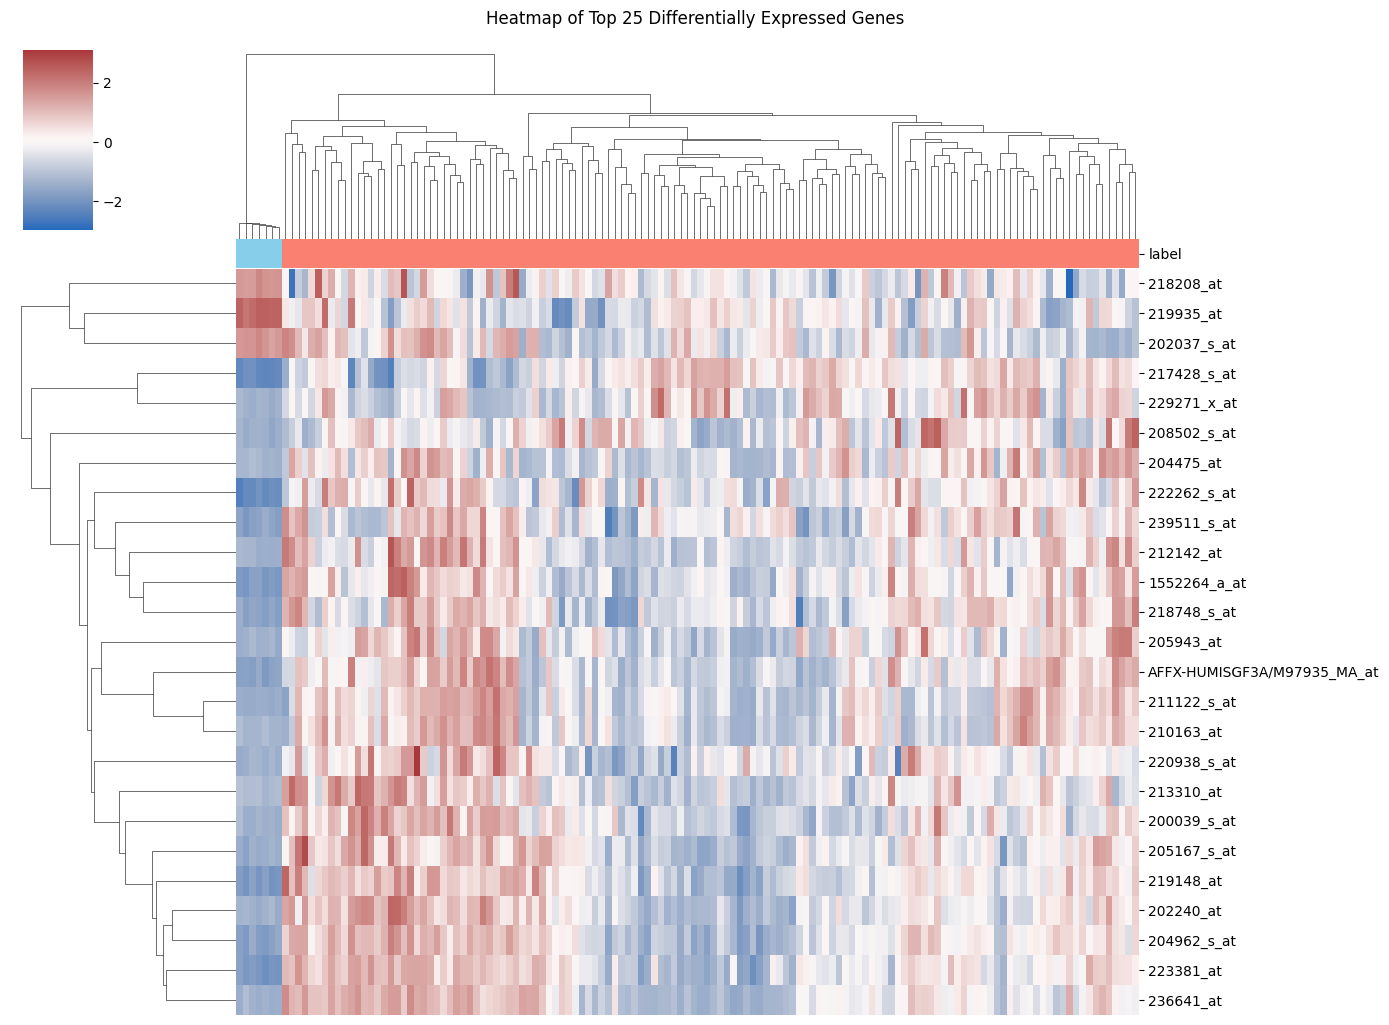

In [ ]:
# Plot and save the clustered heatmap of the top differentially expressed genes

sns.clustermap(
    X_top_scaled.T,
    col_colors=label_colors,
    figsize=(14, 10),
    xticklabels=False,
    yticklabels=True,
    cmap="vlag"
)

plt.suptitle("Heatmap of Top 25 Differentially Expressed Genes", y=1.02)
plt.savefig(result_path + "/figures/heatmap_top25.png")
plt.show()

### Reading the heatmap

The heatmap shows a clear separation between tumor and normal samples based on the top 25 differentially expressed genes. Samples from the same phenotype tend to share similar color patterns, which suggests that these genes capture a strong disease-related expression signal.

Normal samples cluster more tightly and display more uniform expression profiles, suggesting a relatively homogeneous group. Tumor samples appear more heterogeneous, with greater variation in expression across genes. This means that tumor samples still share a common signal, but they also show more internal diversity.

The color contrast across several genes is also strong, with some genes showing higher relative expression in tumors and lower relative expression in normal tissue, and others showing the opposite trend. This pattern is what we would expect from genes selected as strongly differentially expressed.

The dendrogram and the phenotype color bar are not identical by design, but they are broadly consistent. That is an important result, because it shows that the clustering is recovering the biological groups without directly using the labels to build the heatmap.

Overall, the heatmap supports the same conclusion as the volcano plot: tumor and normal tissues differ clearly at the transcriptomic level, and the selected genes provide a useful summary of that difference.